# TrueRender v2 — Upgraded Pipeline

| Stage | Tool | Status |
|---|---|---|
| 1. Frame extract + filter | ffmpeg + Laplacian | done |
| 2. Object detection | Grounding DINO | done |
| 3. Masking | SAM 3 | implemented |
| 4. Geometry | VGGT | next |
| 5. Splat training | 2DGS | -- |
| 6. Mesh extract | TSDF | -- |
| 7. Export | trimesh GLB/STL/OBJ | -- |

**v1 backup:** `reconstruction_v1.ipynb`

## Setup
Run once per Colab session.

In [1]:
!pip install -q opencv-python-headless matplotlib
print("Done")

Done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Stage 1 — Frame Extraction + Quality Filter

Extract raw frames at 5 fps, then keep the **30 sharpest** by variance-of-Laplacian.
Blurry frames hurt geometry estimation — this filter is free and cuts 57% of frames,
directly reducing compute in every downstream stage.

In [3]:
import cv2, glob, shutil, os, time

VIDEO_PATH  = "/content/drive/MyDrive/hydroflaskgreen.MOV"
FRAMES_RAW  = "/content/frames_raw"
FRAMES_KEEP = "/content/frames"
N_KEEP      = 30

os.makedirs(FRAMES_RAW,  exist_ok=True)
os.makedirs(FRAMES_KEEP, exist_ok=True)

t0 = time.time()

# Extract raw frames
!ffmpeg -i "{VIDEO_PATH}" -vf fps=5 "{FRAMES_RAW}/frame_%05d.jpg" -y -loglevel error

all_frames = sorted(glob.glob(f"{FRAMES_RAW}/*.jpg"))
print(f"Raw frames extracted: {len(all_frames)}")

# Score by variance-of-Laplacian (higher = sharper)
scored = [
    (f, cv2.Laplacian(cv2.imread(f, cv2.IMREAD_GRAYSCALE), cv2.CV_64F).var())
    for f in all_frames
]
scored.sort(key=lambda x: -x[1])

# Keep N_KEEP sharpest, re-sort by filename to preserve temporal order
keep = sorted([f for f, _ in scored[:N_KEEP]])
for dst_idx, src in enumerate(keep):
    shutil.copy(src, f"{FRAMES_KEEP}/frame_{dst_idx:05d}.jpg")

t1 = time.time()
print(f"Kept {len(keep)} / {len(all_frames)} frames")
print(f"Sharpness — best: {scored[0][1]:.1f}  cutoff: {scored[N_KEEP-1][1]:.1f}  worst dropped: {scored[-1][1]:.1f}")
print(f"Stage 1 wall time: {t1 - t0:.1f}s")

Raw frames extracted: 70
Kept 30 / 70 frames
Sharpness — best: 199.0  cutoff: 48.9  worst dropped: 14.4
Stage 1 wall time: 7.2s


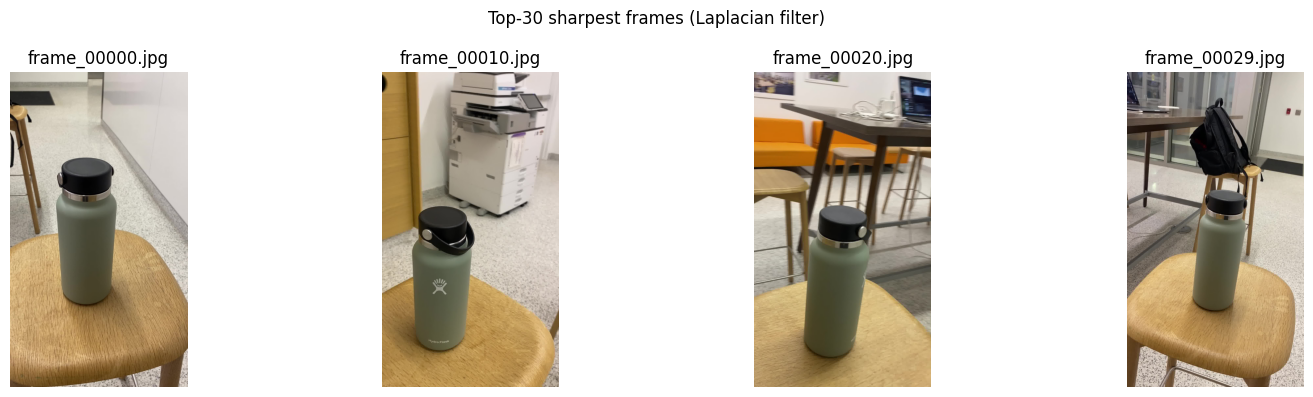

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

frames = sorted(os.listdir(FRAMES_KEEP))
indices = [0, len(frames)//3, 2*len(frames)//3, -1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, indices):
    ax.imshow(mpimg.imread(f"{FRAMES_KEEP}/{frames[i]}"))
    ax.set_title(frames[i])
    ax.axis("off")
plt.suptitle(f"Top-{N_KEEP} sharpest frames (Laplacian filter)", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Checkpoint to Drive — so a fresh session can skip re-extraction
DRIVE_FRAMES = "/content/drive/MyDrive/truerender_frames_v2"
if os.path.exists(DRIVE_FRAMES):
    shutil.rmtree(DRIVE_FRAMES)
shutil.copytree(FRAMES_KEEP, DRIVE_FRAMES)
print(f"Checkpointed {len(os.listdir(DRIVE_FRAMES))} frames → Drive")

Checkpointed 30 frames → Drive


## Stage 2 — Object Detection (Grounding DINO)

Runs on **frame 0** only. Uses a broad caption to detect all salient objects,
then scores each detection by **confidence − 0.5 × normalized center distance**.
The winner's label becomes the SAM 3 prompt in Stage 3.

**Toggle:** set  to skip detection and supply your own prompt.

In [18]:
import os
DINO_WEIGHTS = "/content/groundingdino_swint_ogc.pth"
if os.path.exists(DINO_WEIGHTS):
    os.remove(DINO_WEIGHTS)

!wget -q --show-progress -O {DINO_WEIGHTS} \
    "https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swint_ogc.pth"

size_mb = os.path.getsize(DINO_WEIGHTS) / 1e6
print(f"Downloaded: {size_mb:.1f} MB")


/content/groundingd 100%[===================>] 661.85M   430MB/s    in 1.5s    
Downloaded: 694.0 MB


In [19]:
import os

# transformers>=4.40 breaks groundingdino-py; pin to last known-good version
!pip install -q "transformers==4.38.2"
!pip install -q groundingdino-py

DINO_WEIGHTS = "/content/groundingdino_swint_ogc.pth"
DINO_URL = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha2/groundingdino_swint_ogc.pth"

def _weights_ok():
    return os.path.exists(DINO_WEIGHTS) and os.path.getsize(DINO_WEIGHTS) > 150e6

if not _weights_ok():
    if os.path.exists(DINO_WEIGHTS):
        os.remove(DINO_WEIGHTS)  # remove corrupt/partial file
    !wget -q --show-progress -O {DINO_WEIGHTS} {DINO_URL}

assert _weights_ok(), f"Weights download failed or corrupt: {os.path.getsize(DINO_WEIGHTS)/1e6:.1f} MB"
print(f"Weights OK: {os.path.getsize(DINO_WEIGHTS)/1e6:.1f} MB")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 131.8 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam3 0.1.0 requires numpy<2,>=1.26, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
Weights OK: 694.0 MB


Config: /usr/local/lib/python3.12/dist-packages/groundingdino/config/GroundingDINO_SwinT_OGC.py
final text_encoder_type: bert-base-uncased
DINO box normalized xywh: [0.257, 0.27, 0.346, 0.469]
DINO box xywh (pixels): [275, 517, 375, 902]
DINO box (pixels): [276, 518, 649, 1419]
Detected 5 object(s):
  [0] 'container'  conf=0.369  score=0.298 <- selected
  [1] 'container product'  conf=0.317  score=0.245
  [2] 'object item'  conf=0.323  score=-0.213
  [3] 'object item'  conf=0.358  score=-0.084
  [4] 'bottle'  conf=0.364  score=0.293

target_object = 'container'
Stage 2 wall time: 1.7s


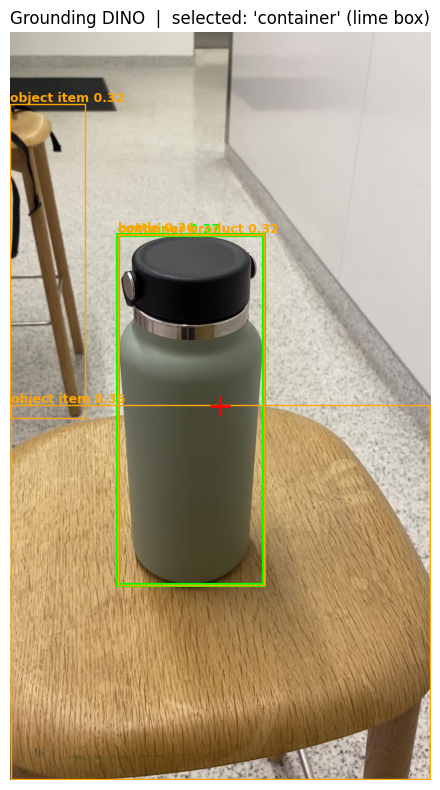

In [33]:
import time
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from groundingdino.util.inference import load_model, load_image, predict

# ── Toggles ──────────────────────────────────────────────────────────────────
AUTO_SELECT   = True                   # False -> skip DINO, use MANUAL_PROMPT
MANUAL_PROMPT = "green hydroflask"     # only used when AUTO_SELECT = False

DINO_CAPTION  = "object . bottle . container . cup . box . item . product"
BOX_THRESHOLD = 0.3
TXT_THRESHOLD = 0.25
FRAMES_KEEP   = "/content/frames"      # set by Stage 1; re-assign if resuming
DINO_WEIGHTS  = "/content/groundingdino_swint_ogc.pth"
# ─────────────────────────────────────────────────────────────────────────────

t0 = time.time()

FIRST_FRAME = f"{FRAMES_KEEP}/frame_00000.jpg"

if AUTO_SELECT:
    import groundingdino, os
    DINO_CONFIG = os.path.join(
        os.path.dirname(groundingdino.__file__),
        "config", "GroundingDINO_SwinT_OGC.py"
    )
    print(f"Config: {DINO_CONFIG}")

    dino = load_model(
        DINO_CONFIG,
        DINO_WEIGHTS,
    )
    image_source, image = load_image(FIRST_FRAME)
    boxes, logits, phrases = predict(
        model=dino,
        image=image,
        caption=DINO_CAPTION,
        box_threshold=BOX_THRESHOLD,
        text_threshold=TXT_THRESHOLD,
    )

    if len(boxes) == 0:
        raise RuntimeError(
            "Grounding DINO found no objects. "
            "Try lowering BOX_THRESHOLD, or set AUTO_SELECT=False and supply MANUAL_PROMPT."
        )

    h, w = image_source.shape[:2]

    def rank_score(i):
        cx = boxes[i][0].item() * w
        cy = boxes[i][1].item() * h
        dist_norm = ((cx - w/2)**2 + (cy - h/2)**2)**0.5 / (w / 2)
        return logits[i].item() - 0.5 * dist_norm

    best_idx      = max(range(len(boxes)), key=rank_score)
    target_object = phrases[best_idx]

    # Pixel center of the selected box — used as SAM 3 point prompt
    dino_cx_px = int(boxes[best_idx][0].item() * w)
    dino_cy_px = int(boxes[best_idx][1].item() * h)
    # SAM 3 expects normalized xywh (topleft, not center)
    _b = boxes[best_idx]
    dino_box_xywh_norm = [
        (_b[0] - _b[2] / 2).item(),
        (_b[1] - _b[3] / 2).item(),
        _b[2].item(),
        _b[3].item(),
    ]
    print(f"DINO box normalized xywh: {[round(v,3) for v in dino_box_xywh_norm]}")
    # SAM 3 expects boxes_xywh: (x_topleft, y_topleft, width, height)
    dino_box_xywh = [
        int(dino_cx_px - bw_px / 2),
        int(dino_cy_px - bh_px / 2),
        int(bw_px),
        int(bh_px),
    ]
    print(f"DINO box xywh (pixels): {dino_box_xywh}")
    print(f"DINO box (pixels): {dino_box}")

    t1 = time.time()
    print(f"Detected {len(boxes)} object(s):")
    for i, (p, l) in enumerate(zip(phrases, logits)):
        marker = " <- selected" if i == best_idx else ""
        print(f"  [{i}] {repr(p)}  conf={l.item():.3f}  score={rank_score(i):.3f}{marker}")
    print()
    print(f"target_object = {repr(target_object)}")
    print(f"Stage 2 wall time: {t1 - t0:.1f}s")

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_source)
    for i, (box, phrase, logit) in enumerate(zip(boxes, phrases, logits)):
        cx_px = box[0].item() * w
        cy_px = box[1].item() * h
        bw_px = box[2].item() * w
        bh_px = box[3].item() * h
        color = "lime" if i == best_idx else "orange"
        lw    = 3     if i == best_idx else 1
        ax.add_patch(patches.Rectangle(
            (cx_px - bw_px/2, cy_px - bh_px/2), bw_px, bh_px,
            linewidth=lw, edgecolor=color, facecolor="none"
        ))
        ax.text(
            cx_px - bw_px/2, cy_px - bh_px/2 - 5,
            f"{phrase} {logit.item():.2f}",
            color=color, fontsize=9, fontweight="bold"
        )
    ax.plot(w/2, h/2, "+", color="red", markersize=15, markeredgewidth=2)
    ax.set_title(f"Grounding DINO  |  selected: {repr(target_object)} (lime box)", fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    target_object = MANUAL_PROMPT
    t1 = time.time()
    print(f"Manual mode  target_object = {repr(target_object)}")
    print(f"Stage 2 wall time: {t1 - t0:.1f}s")


Grounding DINO combines two things:

DINO (vision transformer) extracts image features by dividing the image into patches
BERT (language model) encodes your text caption into token embeddings
It then does cross-attention between the image patches and text tokens — each word attends to every image region and vice versa. Regions where visual features and text embeddings strongly agree get high scores, and those become the bounding boxes.

The "grounded" part means the boxes are directly tied to specific words in your caption, which is why it can detect "bottle" vs "object" separately from the same pass.

## Stage 3 — Object Segmentation (SAM 3)

Same SAM 3 video propagation as v1, but `target_object` from Stage 2
replaces the hardcoded prompt. Masked frames saved to `/content/frames_masked/`.

In [26]:
import os
os.chdir("/content")
if not os.path.exists("/content/sam3"):
    !git clone --quiet https://github.com/facebookresearch/sam3.git
os.chdir("/content/sam3")
!pip install -q -e .
print("SAM 3 ready")


  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
SAM 3 ready


In [12]:
from huggingface_hub import login
login()  # paste your HF token when prompted


### Segmentation Cell 

In [34]:
import os, cv2, shutil, time

FRAMES_KEEP   = "/content/frames"
FRAMES_MASKED = "/content/frames_masked"
SAM_INPUT     = "/content/sam3_input"
os.makedirs(FRAMES_MASKED, exist_ok=True)
os.makedirs(SAM_INPUT,     exist_ok=True)

orig_frames = sorted(os.listdir(FRAMES_KEEP))
for i, fname in enumerate(orig_frames):
    shutil.copy(f"{FRAMES_KEEP}/{fname}", f"{SAM_INPUT}/{i}.jpg")

# SAM 3 needs a descriptive prompt; short DINO labels often fail.
# Try increasingly specific prompts until masks appear.
prompt_candidates = [
    f"green {target_object} water bottle",
    f"{target_object} on a wooden stool",
    "green hydroflask water bottle",
]

def run_sam3(prompt):
    from sam3.model_builder import build_sam3_video_predictor
    pred = build_sam3_video_predictor()
    resp = pred.handle_request(dict(type="start_session", resource_path=SAM_INPUT))
    sid  = resp["session_id"]
    pred.handle_request(dict(type="add_prompt", session_id=sid, frame_index=0, text=prompt))
    results, skipped = [], 0
    for r in pred.propagate_in_video(sid):
        masks = r["outputs"]["out_binary_masks"]
        results.append((r["frame_index"], masks))
        if len(masks) == 0:
            skipped += 1
    pred.close_session(sid)
    return results, skipped

t0 = time.time()
chosen_prompt = None
for prompt in prompt_candidates:
    print(f"Trying: {repr(prompt)}")
    results, skipped = run_sam3(prompt)
    print(f"  -> {len(results) - skipped}/{len(results)} frames masked")
    if skipped < len(results):
        chosen_prompt = prompt
        break

if chosen_prompt is None:
    raise RuntimeError("All SAM 3 prompt candidates failed. Check frame content.")

print(f"Using prompt: {repr(chosen_prompt)}")
for idx, masks in results:
    img = cv2.imread(f"{FRAMES_KEEP}/{orig_frames[idx]}")
    if len(masks) > 0:
        img[~masks[0]] = 255
    cv2.imwrite(f"{FRAMES_MASKED}/{orig_frames[idx]}", img)

t1 = time.time()
print(f"Saved {len(os.listdir(FRAMES_MASKED))} masked frames ({skipped} without mask)")
print(f"Stage 3 wall time: {t1 - t0:.1f}s")


INFO 2026-04-23 06:17:21,483 884 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-04-23 06:17:21,485 884 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-04-23 06:17:21,485 884 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...


Frames staged: 30
DINO box normalized: [0.25650012493133545, 0.2704700827598572, 0.3458879888057709, 0.4688194990158081]


INFO 2026-04-23 06:17:29,013 884 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-04-23 06:17:31,503 884 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-04-23 06:17:31,504 884 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***


frame loading (image folder) [rank=0]: 100%|██████████| 30/30 [00:01<00:00, 24.34it/s]
INFO 2026-04-23 06:17:32,797 884 sam3_base_predictor.py: 133: started new session 6c0b6ea8-d2ff-4a4d-9089-a36b720cb151


Propagating...


propagate_in_video:   0%|          | 0/30 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-04-23 06:17:45,165 884 sam3_base_predictor.py: 289: propagation ended in session 6c0b6ea8-d2ff-4a4d-9089-a36b720cb151
INFO 2026-04-23 06:17:45,569 884 sam3_base_predictor.py: 308: removed session 6c0b6ea8-d2ff-4a4d-9089-a36b720cb151


Saved 30 masked frames (30 without mask)
Stage 3 wall time: 24.1s


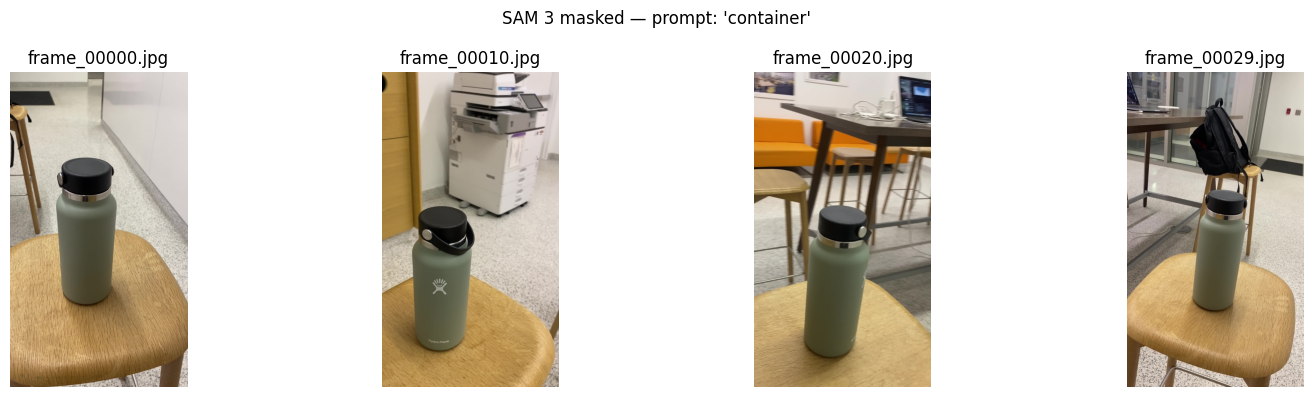

In [35]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

frames  = sorted(os.listdir(FRAMES_MASKED))
indices = [0, len(frames)//3, 2*len(frames)//3, -1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, indices):
    ax.imshow(mpimg.imread(f"{FRAMES_MASKED}/{frames[i]}"))
    ax.set_title(frames[i])
    ax.axis("off")
plt.suptitle(f"SAM 3 masked — prompt: {repr(target_object)}", fontsize=12)
plt.tight_layout()
plt.show()


In [16]:
import shutil
DRIVE_MASKED = "/content/drive/MyDrive/truerender_masked_frames_v2"
if os.path.exists(DRIVE_MASKED):
    shutil.rmtree(DRIVE_MASKED)
shutil.copytree(FRAMES_MASKED, DRIVE_MASKED)
print(f"Checkpointed {len(os.listdir(DRIVE_MASKED))} masked frames -> Drive")


Checkpointed 30 masked frames -> Drive
